In [4]:
from parse_full_results import get_full_try_exps_dataframe
import copy
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 3
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['axes.titlesize']=12
plt.rcParams['axes.labelsize']=12
plt.rcParams['figure.figsize'] = (8.0, 8.0)
plt.rcParams['font.size'] = 14

plt.rcParams['axes.formatter.use_locale'] = True

In [5]:
df = get_full_try_exps_dataframe()

In [6]:
columns = df.columns
df.rename(columns = {'class':'model_class', 'num_samples':'samples_num'}, inplace=True)
df

,model_class,train_loss,val_loss,train_acc,val_acc,deviation,save_log_path,num_epochs,loader_size,layers_num,hidden_channels,kernel_size,output_channels,num_params,sigma,samples_num
0,conv,1.232622,1.275252,0.567935,0.550557,0.259070,results/hc_128/7_0,1,-1,1,128,3,8,84818,3,32
1,conv,1.230204,1.274305,0.569653,0.544885,0.132619,results/hc_128/2_0,1,-1,1,128,3,8,84818,3,32
2,conv,1.239740,1.282589,0.564338,0.541302,0.177398,results/hc_128/6_0,1,-1,1,128,3,8,84818,3,32
3,conv,1.224552,1.263301,0.570532,0.553543,0.202417,results/hc_128/1_0,1,-1,1,128,3,8,84818,3,32
4,conv,1.265977,1.312188,0.554847,0.530852,0.158106,results/hc_128/5_0,1,-1,1,128,3,8,84818,3,32
5,conv,1.244179,1.283606,0.561021,0.541899,0.176657,results/hc_128/0_0,1,-1,1,128,3,8,84818,3,32
6,conv,1.246470,1.287929,0.562180,0.546278,0.181812,results/hc_128/3_0,1,-1,1,128,3,8,84818,3,32
7,conv,1.270830,1.313134,0.549153,0.535231,0.144249,results/hc_128/4_0,1,-1,1,128,3,8,84818,3,32
1431,conv,1.264902,1.310964,0.559323,0.536525,0.122539,results/hc512/6_0,1,-1,1,512,3,8,123218,3,32
1432,conv,1.215583,1.260580,0.576866,0.548766,0.115491,results/hc512/1_0,1,-1,1,512,3,8,123218,3,32


In [4]:
def describe_exps(df, describe_in_column = None):
    if describe_in_column is not None:
        final_rows = []
        for target_col in np.unique(df[describe_in_column]):
            current_row = {describe_in_column:target_col}
            for column in ['num_epochs', 'layers_num', 'hidden_channels']:
                if column == describe_in_column:
                    continue
                current_row[f'unique {column}'] = len(np.unique(np.array(df.query(f'{describe_in_column} == {target_col}')[column])))
            final_rows.append(current_row)
        print(current_row.keys())
        display(pd.DataFrame(final_rows, columns = current_row.keys()))
    else:
        print(f'number of unique')
        for column in ['num_epochs', 'layers_num', 'hidden_channels']:
            print(column, ':', len(np.unique(np.array(df[column]))))
print()
describe_exps(df, describe_in_column='layers_num')
describe_exps(df, describe_in_column='hidden_channels')


dict_keys(['layers_num', 'unique num_epochs', 'unique hidden_channels'])


,layers_num,unique num_epochs,unique hidden_channels
0,1,7,7
1,2,7,4
2,3,7,4
3,4,7,4
4,5,7,4
5,6,7,4
6,7,7,4
7,8,7,4
8,9,7,4
9,10,7,4


dict_keys(['hidden_channels', 'unique num_epochs', 'unique layers_num'])


,hidden_channels,unique num_epochs,unique layers_num
0,64,7,16
1,128,7,16
2,256,7,10
3,512,7,11
4,1024,6,1
5,2048,5,1
6,4096,7,1


In [5]:
def compare_same_params(same_params_dict, 
                        target_params, 
                        supported_changes_params, 
                        df = df, 
                        enable_valid = True,
                        params_in_suptitle = None):
    columns = list(same_params_dict.keys()) + [target_params] + ['deviation'] + train_log_columns + [supported_changes_params]
    def wrap(elem):
        if isinstance(elem, str):
            elem = '\"' + elem + '\"'
        return elem
    query = ' and '.join([f'{key} == {wrap(value)}' for key, value in same_params_dict.items()])
    df = df[columns].query(query)
    fig, axs = plt.subplots(3, figsize = (15, 12))
    if params_in_suptitle is not None:
        fig.suptitle([f'{key}:{same_params_dict[key]}' for key in params_in_suptitle])
    colors = sns.color_palette()
    mod = len(colors)
    for i, supported_param in enumerate(np.unique(df[supported_changes_params])):
        df_with_supported = copy.deepcopy(df)
        df_with_supported.query(f'{supported_changes_params} == {supported_param}', inplace = True)
        sns.pointplot(
            x=target_params, 
            y='deviation',
            data=df_with_supported, ax = axs[0], 
            label = supported_param, 
            color = colors[i%mod])
        sns.pointplot(
            x=target_params, 
            y='train_loss', 
            data=df_with_supported, ax = axs[1], 
            label = f'{supported_param}',
            color = colors[i%mod]);
        if enable_valid:
            sns.pointplot(
                x=target_params, 
                y='val_loss', 
                data=df_with_supported, ax = axs[1],
                color = colors[i%mod]);
        sns.pointplot(
            x=target_params, 
            y='train_acc', 
            data=df_with_supported, 
            ax = axs[2], 
            label= f'{supported_param}',
            color = colors[i%mod]
        );
        if enable_valid:
            sns.pointplot(
                x=target_params, 
                y='val_acc', 
                data=df_with_supported, 
                ax = axs[2], 
                color = colors[i%mod]);

    for i in range(3):
        axs[i].legend(title = supported_changes_params)
    axs[1].set_ylabel('Loss')
    axs[2].set_ylabel('Accuracy')


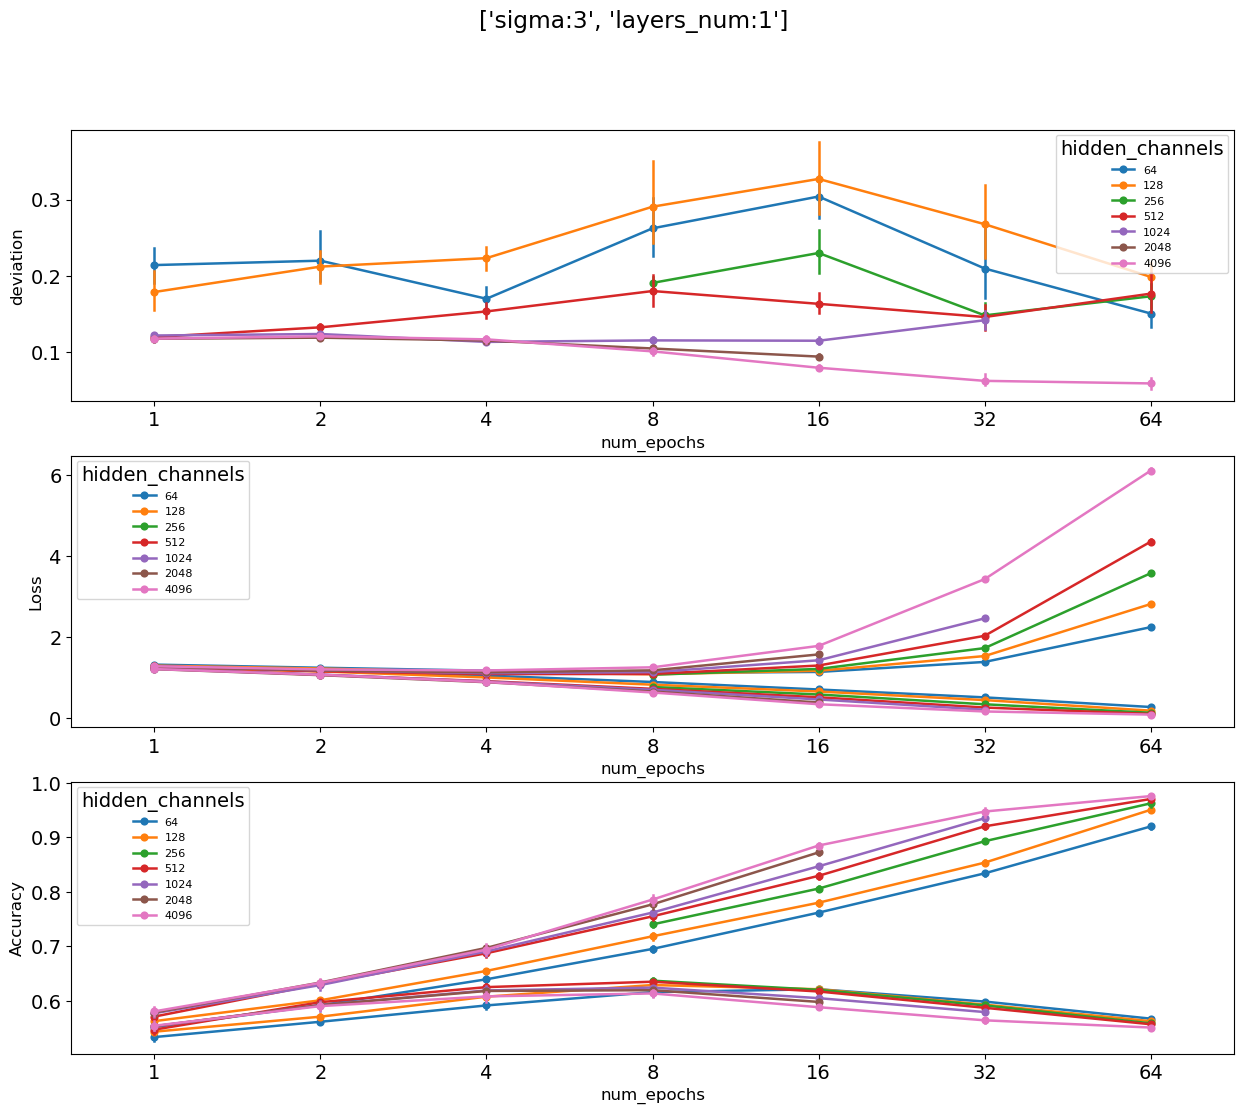

In [6]:
same_params = {
    'model_class':'conv',
    
    'loader_size':-1,
    'layers_num':1,
    'kernel_size':3,
    'output_channels':8,
    'sigma':3,
    'samples_num':32
}
target_params = 'num_epochs'
supported_changes_params = 'hidden_channels'
train_log_columns = ['train_loss', 'val_loss', 'train_acc', 'val_acc']

compare_same_params(same_params, 
                    target_params, 
                    supported_changes_params, 
                    enable_valid=True, 
                    params_in_suptitle=['sigma', 'layers_num'])

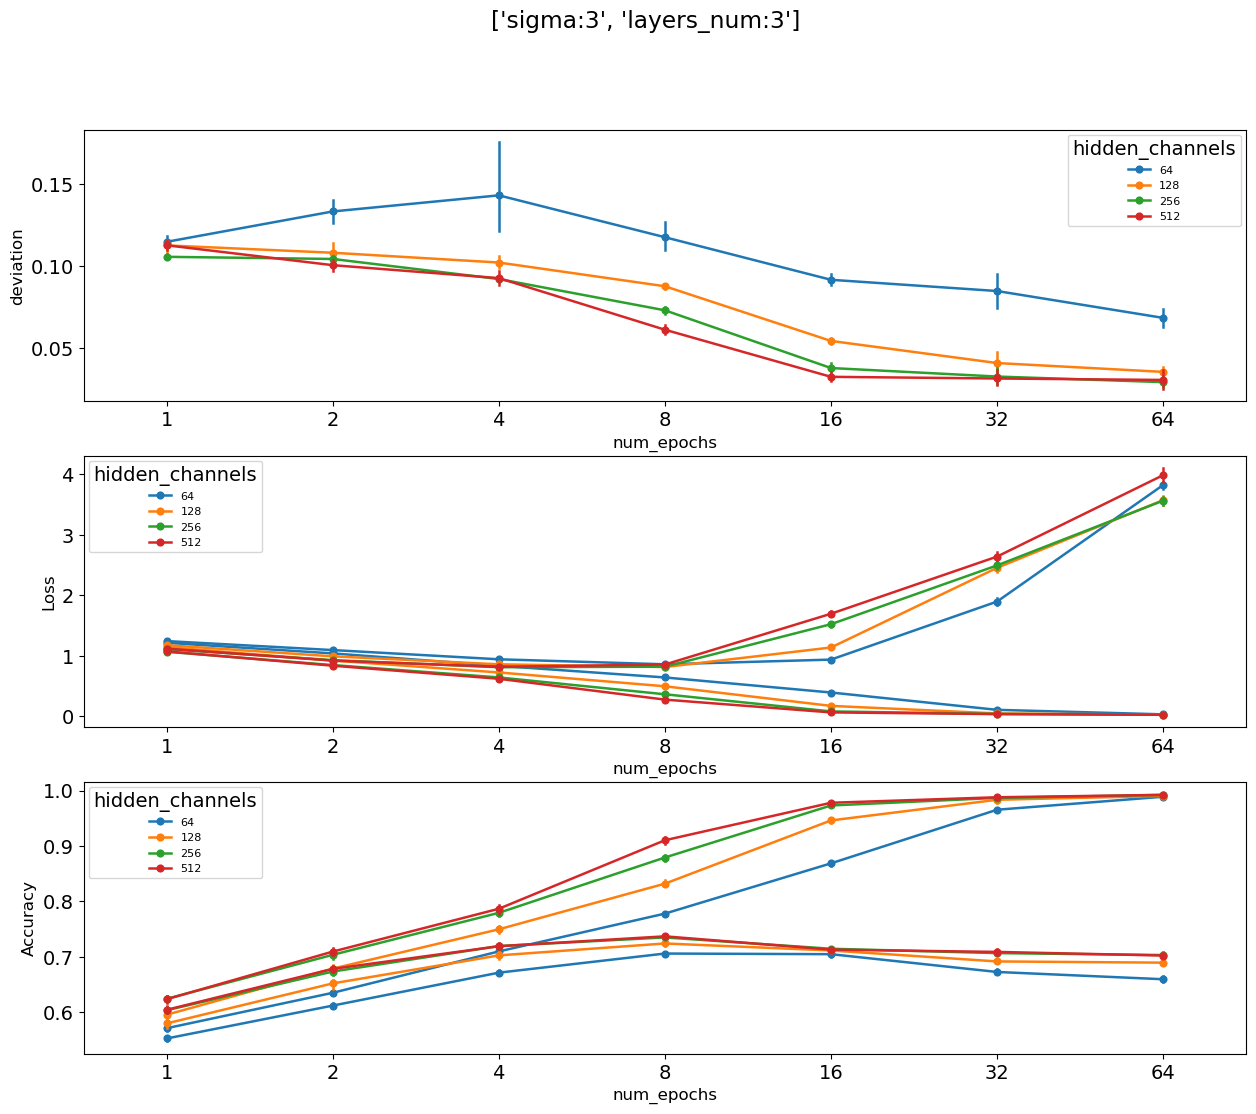

In [7]:
same_params = {
    'model_class':'conv',
    
    'loader_size':-1,
    'layers_num':3,
    'kernel_size':3,
    'output_channels':8,
    'sigma':3,
    'samples_num':32
}
target_params = 'num_epochs'
supported_changes_params = 'hidden_channels'
train_log_columns = ['train_loss', 'val_loss', 'train_acc', 'val_acc']

compare_same_params(same_params, 
                    target_params, 
                    supported_changes_params, 
                    enable_valid=True, 
                    params_in_suptitle=['sigma', 'layers_num'])

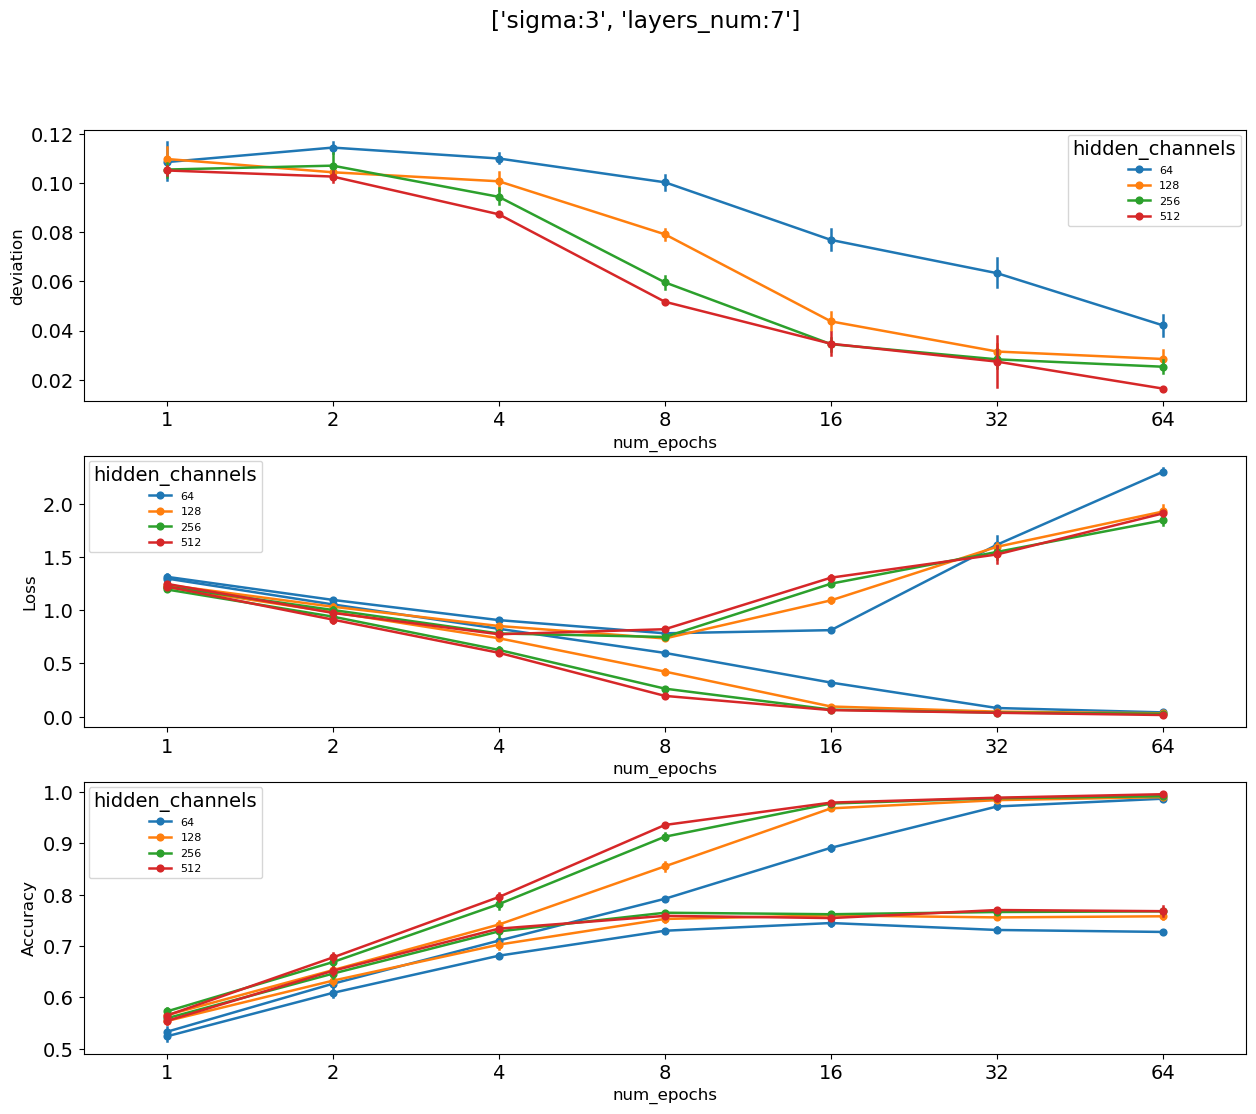

In [8]:
same_params = {
    'model_class':'conv',
    
    'loader_size':-1,
    'layers_num':7,
    'kernel_size':3,
    'output_channels':8,
    'sigma':3,
    'samples_num':32
}
target_params = 'num_epochs'
supported_changes_params = 'hidden_channels'
train_log_columns = ['train_loss', 'val_loss', 'train_acc', 'val_acc']

compare_same_params(same_params, 
                    target_params, 
                    supported_changes_params,
                    enable_valid=True, 
                    params_in_suptitle=['sigma', 'layers_num'])

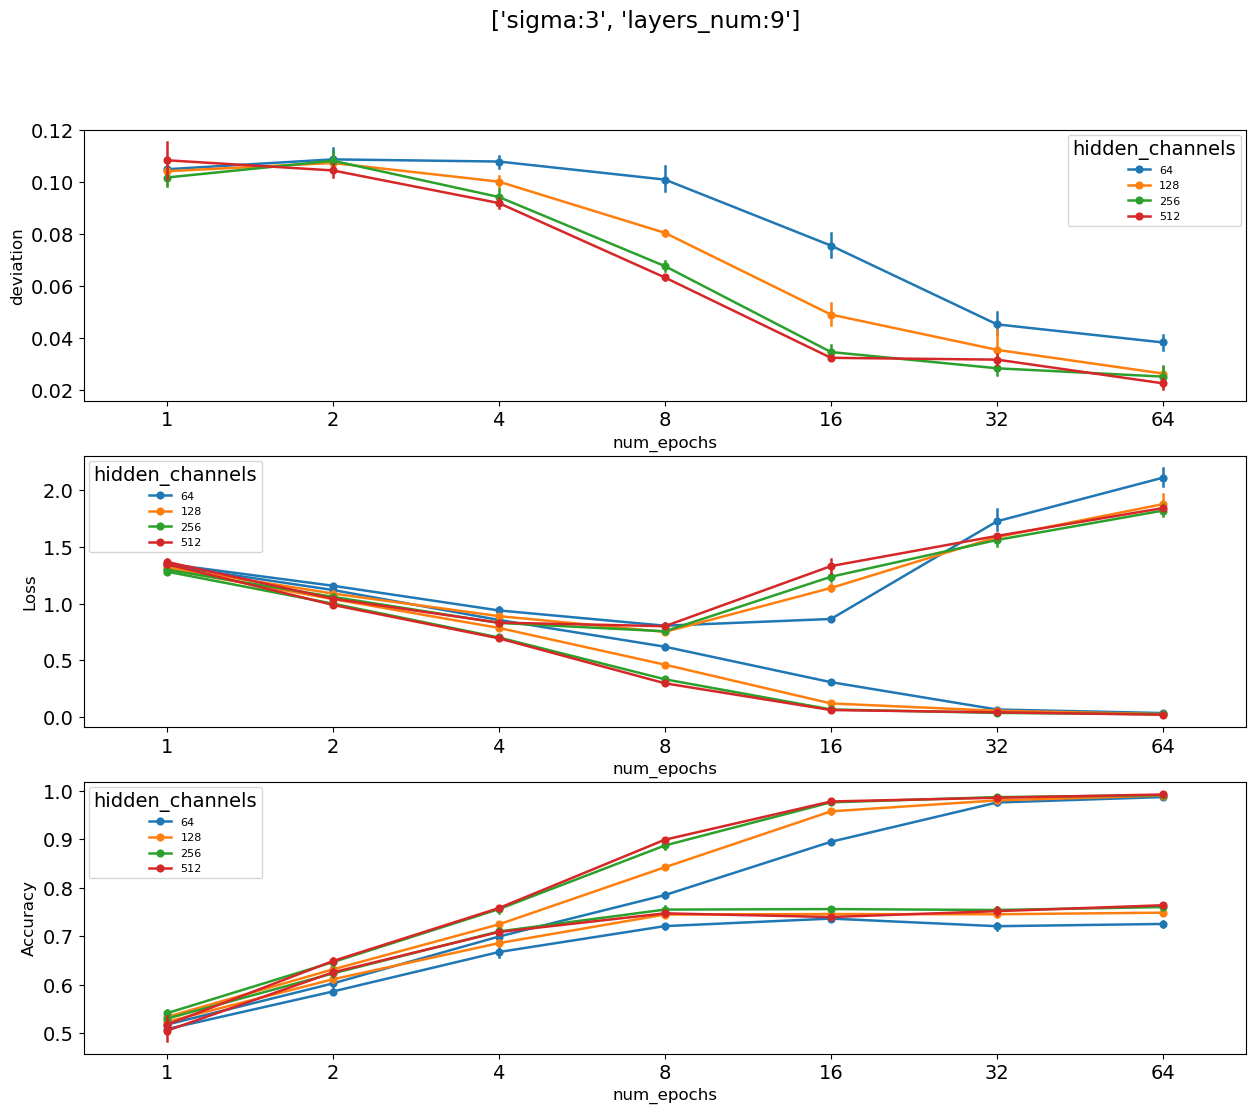

In [9]:
same_params = {
    'model_class':'conv',
    
    'loader_size':-1,
    'layers_num':9,
    'kernel_size':3,
    'output_channels':8,
    'sigma':3,
    'samples_num':32
}
target_params = 'num_epochs'
supported_changes_params = 'hidden_channels'
train_log_columns = ['train_loss', 'val_loss', 'train_acc', 'val_acc']

compare_same_params(same_params, 
                    target_params, 
                    supported_changes_params,
                    enable_valid=True, 
                    params_in_suptitle=['sigma', 'layers_num'])

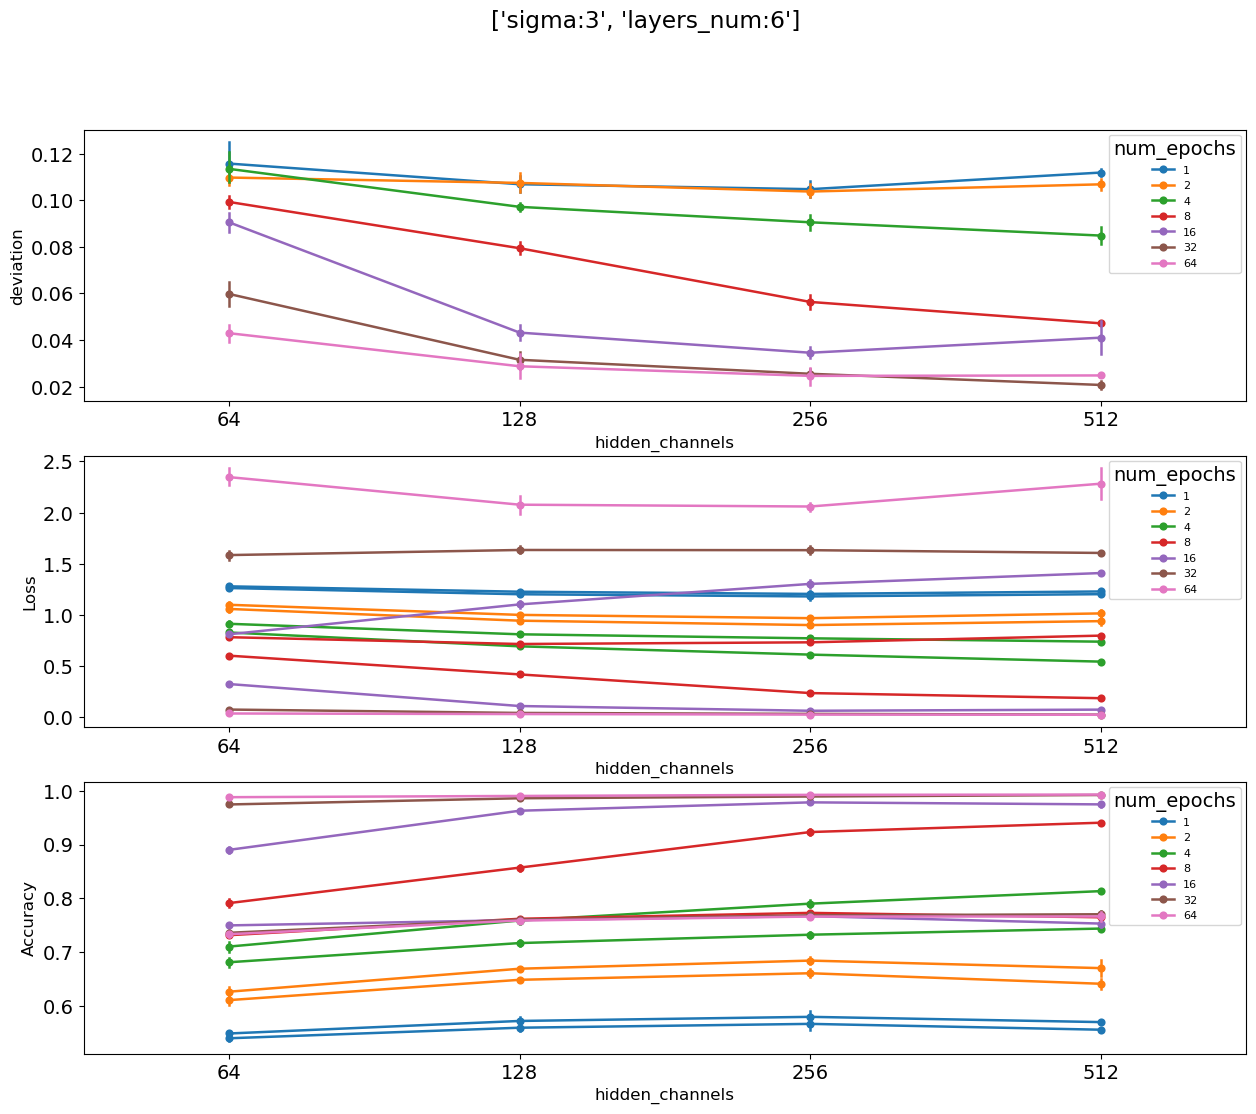

In [10]:
same_params = {
    'model_class':'conv',
    
    'loader_size':-1,
    'layers_num':6,
    'kernel_size':3,
    'output_channels':8,
    'sigma':3,
    'samples_num':32
}
target_params = 'hidden_channels'
supported_changes_params = 'num_epochs'
train_log_columns = ['train_loss', 'val_loss', 'train_acc', 'val_acc']

compare_same_params(same_params, 
                    target_params, 
                    supported_changes_params,
                    enable_valid=True, 
                    params_in_suptitle=['sigma', 'layers_num'])

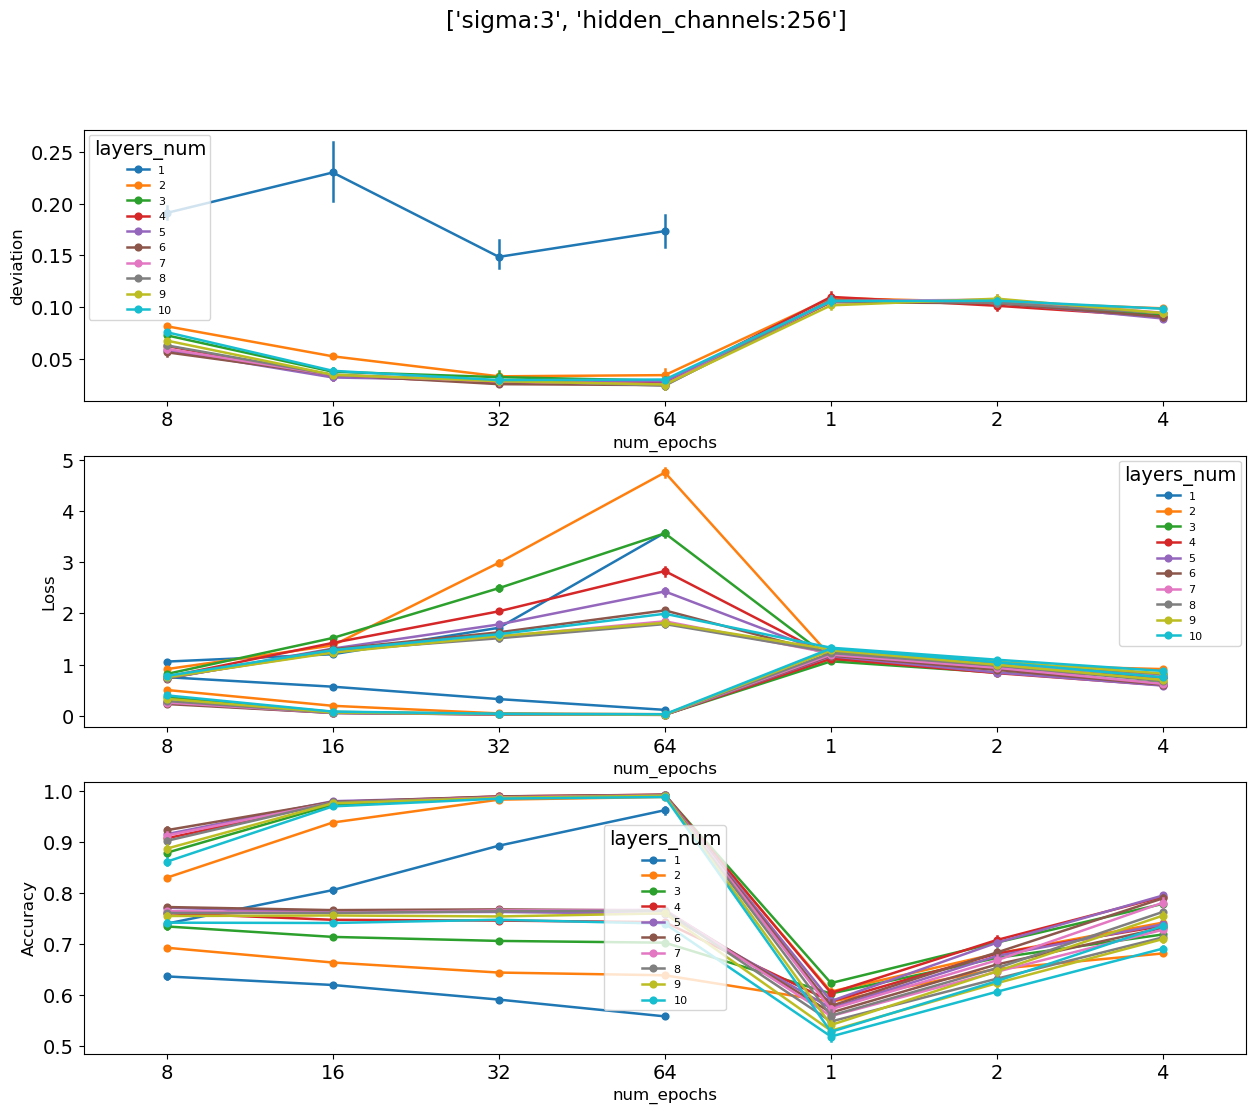

In [11]:
same_params = {
    'model_class':'conv',
    
    'loader_size':-1,
    'hidden_channels':256,
    'kernel_size':3,
    'output_channels':8,
    'sigma':3,
    'samples_num':32
}
target_params = 'num_epochs'
supported_changes_params = 'layers_num'
train_log_columns = ['train_loss', 'val_loss', 'train_acc', 'val_acc']

compare_same_params(same_params, 
                    target_params, 
                    supported_changes_params,
                    enable_valid=True, 
                    params_in_suptitle=['sigma', 'hidden_channels'])

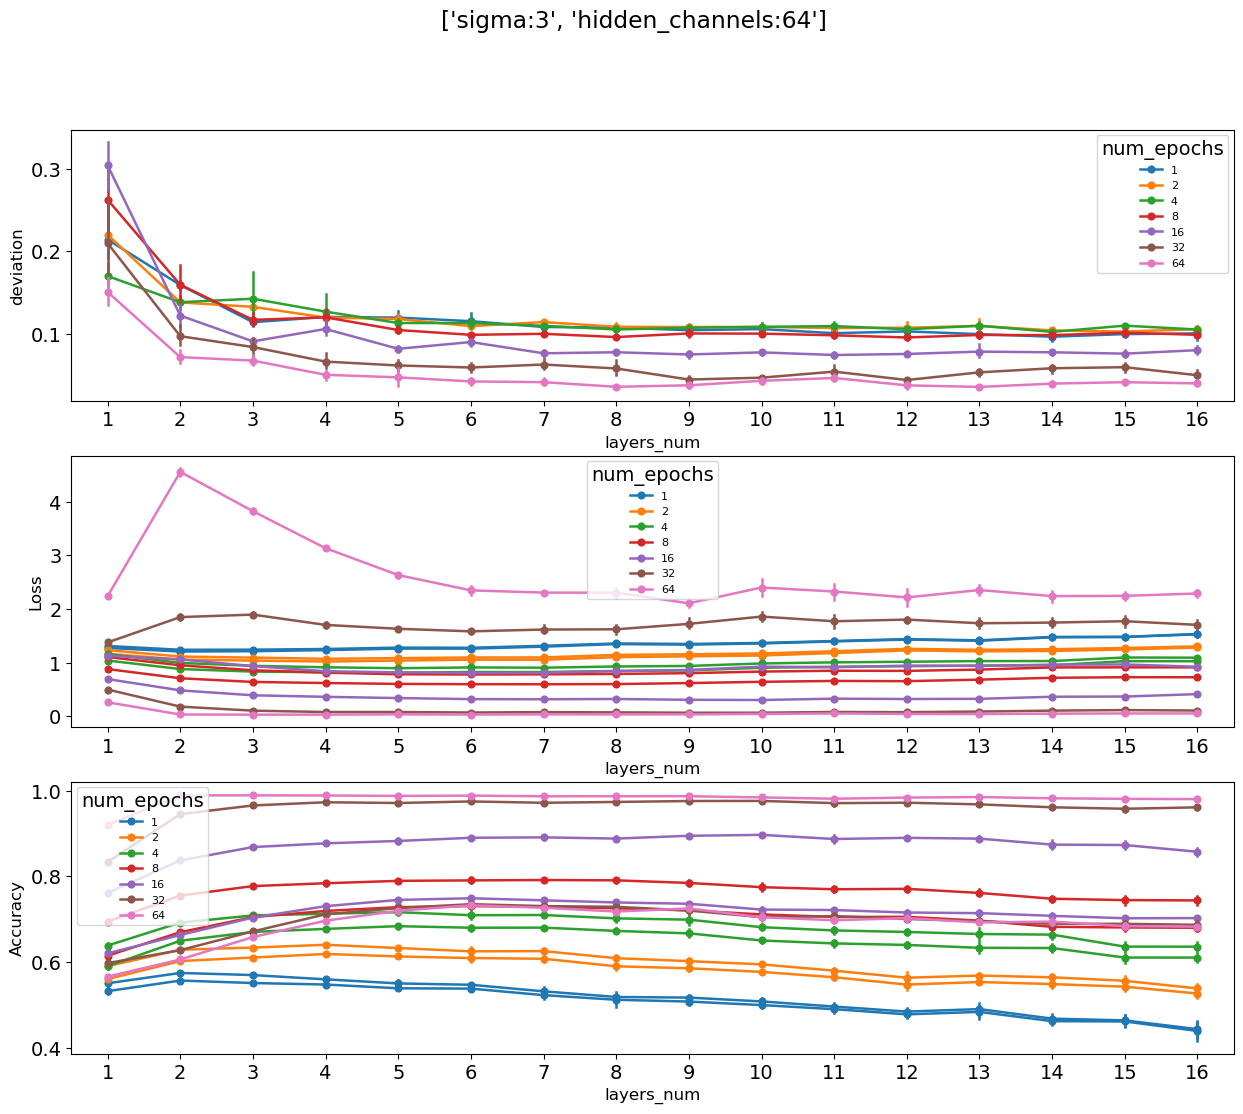

In [12]:
same_params = {
    'model_class':'conv',
    
    'loader_size':-1,
    'hidden_channels':64,
    'kernel_size':3,
    'output_channels':8,
    'sigma':3,
    'samples_num':32
}
target_params = 'layers_num'
supported_changes_params = 'num_epochs'
train_log_columns = ['train_loss', 'val_loss', 'train_acc', 'val_acc']

compare_same_params(same_params, 
                    target_params, 
                    supported_changes_params,
                    enable_valid=True, 
                    params_in_suptitle=['sigma', 'hidden_channels'])

In [13]:
df.query('layers_num == 6 and num_epochs == 64 and hidden_channels == 64')

,model_class,train_loss,val_loss,train_acc,val_acc,deviation,save_log_path,num_epochs,loader_size,layers_num,hidden_channels,kernel_size,output_channels,num_params,sigma,samples_num
2096,conv,0.034352,2.235260,0.987652,0.735072,0.039562,results/hc64/1_41,64,-1,6,64,3,8,263058,3,32
2097,conv,0.020920,2.266494,0.993007,0.739948,0.037790,results/hc64/2_41,64,-1,6,64,3,8,263058,3,32
2098,conv,0.041216,2.288485,0.985973,0.735171,0.045167,results/hc64/7_41,64,-1,6,64,3,8,263058,3,32
2099,conv,0.040269,2.469583,0.985894,0.733977,0.051715,results/hc64/0_41,64,-1,6,64,3,8,263058,3,32
2100,conv,0.028847,2.284996,0.990129,0.726214,0.034569,results/hc64/4_41,64,-1,6,64,3,8,263058,3,32
2101,conv,0.036297,2.505055,0.987512,0.727408,0.045057,results/hc64/5_41,64,-1,6,64,3,8,263058,3,32
2102,conv,0.044027,2.526419,0.984595,0.720939,0.048263,results/hc64/6_41,64,-1,6,64,3,8,263058,3,32
2103,conv,0.028065,2.195538,0.990409,0.744526,0.041688,results/hc64/3_41,64,-1,6,64,3,8,263058,3,32
